# Cluster centroids: where did the electron land?

A cluster is the few pixels one electron fired (notebook 02). To make an image, each cluster has to be
reduced to one point: an estimate of **where the electron entered the sensor**. The obvious candidates:

| estimator | rule |
|---|---|
| `brightest` | center of the pixel with the highest ToT |
| `centroid` | plain mean of the pixel centers |
| `weighted` | ToT-weighted mean of the pixel centers (what `kronos.cluster` stores) |
| `η-corrected` | `weighted`, with its sub-pixel part remapped so impacts fill each pixel evenly |

They disagree by up to half a pixel, and the real data alone cannot say which is right, because no
one knows where the electrons really landed. So this notebook builds that knowledge:

1. Reduce the run to per-cluster sums from which every estimator follows, in the same pass that sorts
   and clusters (sections 1–2).
2. See what the real data can and cannot tell (sections 3–4).
3. **Simulate** electrons in silicon, and **fit the detector's response** so the simulated clusters
   look like the real ones. Now every cluster has a known entry point (sections 5–6).
4. Learn from the simulation where the entry point sits, and **fit a simple model** to it: the best
   centroid turns out to be an average of `centroid` and `weighted` (section 7).
5. **Test** that model on a sharp edge in the real beam (section 8).

The beam energy is the one physics input (`E_BEAM_KEV`).

In [1]:
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numba
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize
from matplotlib.patches import Rectangle
from plot_style import AQUA, BLUE, INK, INK_2, MAGENTA, MUTED, ORANGE, PANEL, RED, SEQUENTIAL, SURFACE, VIOLET, YELLOW, no_grid
from scipy.optimize import curve_fit
from scipy.special import erf

from kronos.cluster import cluster_tables, label_events
from kronos.sort import merge_sort

%matplotlib ipympl

In [2]:
E_BEAM_KEV = 60.0  # accelerating voltage in kV = electron kinetic energy in keV
PIXEL_UM = 55.0  # Timepix4 pixel pitch
SENSOR_UM = 300.0  # silicon thickness (assumed)
BIAS_V = 100.0  # sensor bias (assumed), only for the diffusion estimate

data_directory = Path('/Users/7c2/Desktop/Projects/TimePix/data/2026_09_30_tp4_firsttry')
files = sorted(data_directory.glob('austin_test_*.h5'))
WIDTH, HEIGHT = 448, 512
DT_MAX = 1  # notebook 02

# One color and marker per estimator, in every figure.
POSITION = {'brightest': (BLUE, 's'), 'centroid': (AQUA, 'X'), 'weighted': (VIOLET, 'o'), 'η-corrected': (MAGENTA, 'D'), 'blend': (RED, '*')}

## 1. One pass: sort, cluster, keep the cluster sums

Every estimator above needs only a few sums per cluster, taken relative to the cluster's brightest
pixel: the number of pixels `n`, the summed ToT, Σdx and Σdy (for `centroid`) and Σ ToT·dx and
Σ ToT·dy (for `weighted`). `kronos.cluster.cluster_tables` accepts any per-cluster summary, so these
sums are collected in the same pass that sorts and clusters the run (notebook 01). The sums are small
integers, so the table is exact and compact, and the events themselves can be dropped.

In [3]:
@numba.njit(cache=True)
def _cluster_sums(labels, x, y, tot, n_clusters):
    # Brightest event per cluster (highest ToT, ties to the earlier one), then sums of offsets from it.
    bright = np.full(n_clusters, -1, np.int64)
    for i in range(len(labels)):
        k = labels[i]
        if bright[k] < 0 or tot[i] > tot[bright[k]]:
            bright[k] = i
    sums = np.zeros((6, n_clusters), np.int64)  # n, Σdx, Σdy, ΣToT, ΣToT·dx, ΣToT·dy
    for i in range(len(labels)):
        k = labels[i]
        dx, dy = x[i] - x[bright[k]], y[i] - y[bright[k]]
        sums[0, k] += 1
        sums[1, k] += dx
        sums[2, k] += dy
        sums[3, k] += tot[i]
        sums[4, k] += tot[i] * dx
        sums[5, k] += tot[i] * dy
    return bright, sums


def cluster_sums(events, labels):
    # One row per cluster label: the sums every estimator is built from.
    x, y, tot = (np.asarray(events[name], np.int64) for name in ('x', 'y', 'tot'))
    bright, sums = _cluster_sums(labels, x, y, tot, labels.max() + 1)
    n, s_dx, s_dy, total, w_dx, w_dy = sums
    return pd.DataFrame(
        {
            'n': n.astype(np.uint16),
            'tot': total.astype(np.int32),
            'x_b': x[bright].astype(np.uint16),
            'y_b': y[bright].astype(np.uint16),
            'tot_b': tot[bright].astype(np.uint16),
            's_dx': s_dx.astype(np.int16),
            's_dy': s_dy.astype(np.int16),
            'w_dx': w_dx.astype(np.int32),
            'w_dy': w_dy.astype(np.int32),
        }
    )


start = time.perf_counter()
stats = pd.concat(cluster_tables(merge_sort(files), DT_MAX, summarize=cluster_sums), ignore_index=True)
print(
    f'{stats.n.sum():,} events -> {len(stats):,} clusters in {time.perf_counter() - start:.0f} s; {stats.memory_usage(index=False).sum() / len(stats):.0f} bytes per cluster'
)

sample = next(merge_sort(files))  # the first part, with its events kept for drawing examples
sample_labels = label_events(sample['x'], sample['y'], sample['toa'], DT_MAX)
sample_stats = cluster_sums(sample, sample_labels)

85,180,304 events -> 47,786,372 clusters in 4 s; 24 bytes per cluster


## 2. The estimators, from the sums

With **u** = (`weighted` − `brightest`), the ToT-weighted offset from the brightest pixel:

* `centroid` = brightest + (Σdx, Σdy)/n; `weighted` = brightest + **u**.
* **η-correction.** Write a position as pixel + sub-pixel part `f ∈ [−½, ½)`. Under even
  illumination true impacts fill each pixel evenly, so a good estimator's `f` should be uniform.
  `weighted`'s is not, because charge sharing is not linear in where the electron hit. The
  η-correction maps `f` through its own cumulative distribution, `f′ = CDF(f) − ½`, separately in x and
  y: the one order-preserving remap that makes `f′` uniform. (A single-pixel cluster has `f = 0` and
  stays at its pixel center; no remap can spread out a point.)

In [4]:
def positions(table, eta=None):
    # Impact (x, y) of each estimator, in pixels with pixel centers at integers.
    xb, yb = table.x_b.to_numpy(np.float32), table.y_b.to_numpy(np.float32)
    n, w = table.n.to_numpy(np.float32), table.tot.to_numpy(np.float32)
    ux = np.where(w > 0, table.w_dx / np.maximum(w, 1), table.s_dx / n).astype(np.float32)  # ToT-0 clusters: unweighted
    uy = np.where(w > 0, table.w_dy / np.maximum(w, 1), table.s_dy / n).astype(np.float32)
    out = {
        'brightest': (xb, yb),
        'centroid': (xb + table.s_dx.to_numpy(np.float32) / n, yb + table.s_dy.to_numpy(np.float32) / n),
        'weighted': (xb + ux, yb + uy),
    }
    if eta is not None:
        out['η-corrected'] = tuple(apply_eta(v, sorted_f) for v, sorted_f in zip(out['weighted'], eta))
    return out


def subpixel(v):
    return v - np.floor(v + 0.5)


def measure_eta(values, n_sample=4_000_000, seed=0):
    # Sorted sub-pixel parts of a random sample: an empirical CDF.
    pick = np.random.default_rng(seed).choice(len(values), min(n_sample, len(values)), replace=False)
    return np.sort(subpixel(values[pick]))


def apply_eta(v, sorted_f):
    # f' = CDF(f) - 1/2, mid-rank for ties, so the point mass at f = 0 stays at 0.
    f = subpixel(v)
    rank = (np.searchsorted(sorted_f, f, 'left') + np.searchsorted(sorted_f, f, 'right')) / 2
    return (v - f + rank / len(sorted_f) - 0.5).astype(np.float32)


eta = tuple(measure_eta(v) for v in positions(stats)['weighted'])
impact = positions(stats, eta)
sample_impact = positions(sample_stats, eta)

# Check: the sums reproduce the estimators computed straight from the events.
x, y, tot = (sample[name].astype(np.float64) for name in ('x', 'y', 'tot'))
n, w = np.bincount(sample_labels), np.bincount(sample_labels, tot)
direct = {
    'centroid': np.bincount(sample_labels, x) / n,
    'weighted': np.where(w > 0, np.bincount(sample_labels, tot * x) / np.maximum(w, 1), np.bincount(sample_labels, x) / n),
}
print('sums reproduce centroid and weighted from the events:', all(np.allclose(sample_impact[name][0], direct[name], atol=1e-4) for name in direct))


def draw_pixels(ax, px, py, ptot, impacts, center):
    # A cluster as shaded pixels (number = ToT) and one marker per estimator, around center.
    norm = Normalize(0, max(ptot.max(), 1))
    for qx, qy, q in zip(px, py, ptot):
        ax.add_patch(
            Rectangle((qx - center[0] - 0.5, qy - center[1] - 0.5), 1, 1, facecolor=SEQUENTIAL(0.15 + 0.7 * norm(q)), edgecolor=SURFACE, lw=2)
        )
        ax.text(qx - center[0] - 0.44, qy - center[1] + 0.44, f'{q:.0f}', ha='left', va='top', fontsize=7, color='white' if norm(q) > 0.6 else INK_2)
    for name, (ix, iy) in impacts.items():
        color, marker = POSITION[name]
        ax.plot(
            ix - center[0],
            iy - center[1],
            marker=marker,
            ms=11 if marker == '*' else 8,
            mfc='none' if name == 'brightest' else color,
            mec=color,
            mew=1.6,
            ls='none',
            label=name,
            zorder=5,
        )
    ax.set(xlim=(-2, 2), ylim=(-2, 2), aspect='equal')
    no_grid(ax)
    ax.set_facecolor(PANEL)

sums reproduce centroid and weighted from the events: True


Eight real clusters and where each estimator puts the electron (number = ToT):

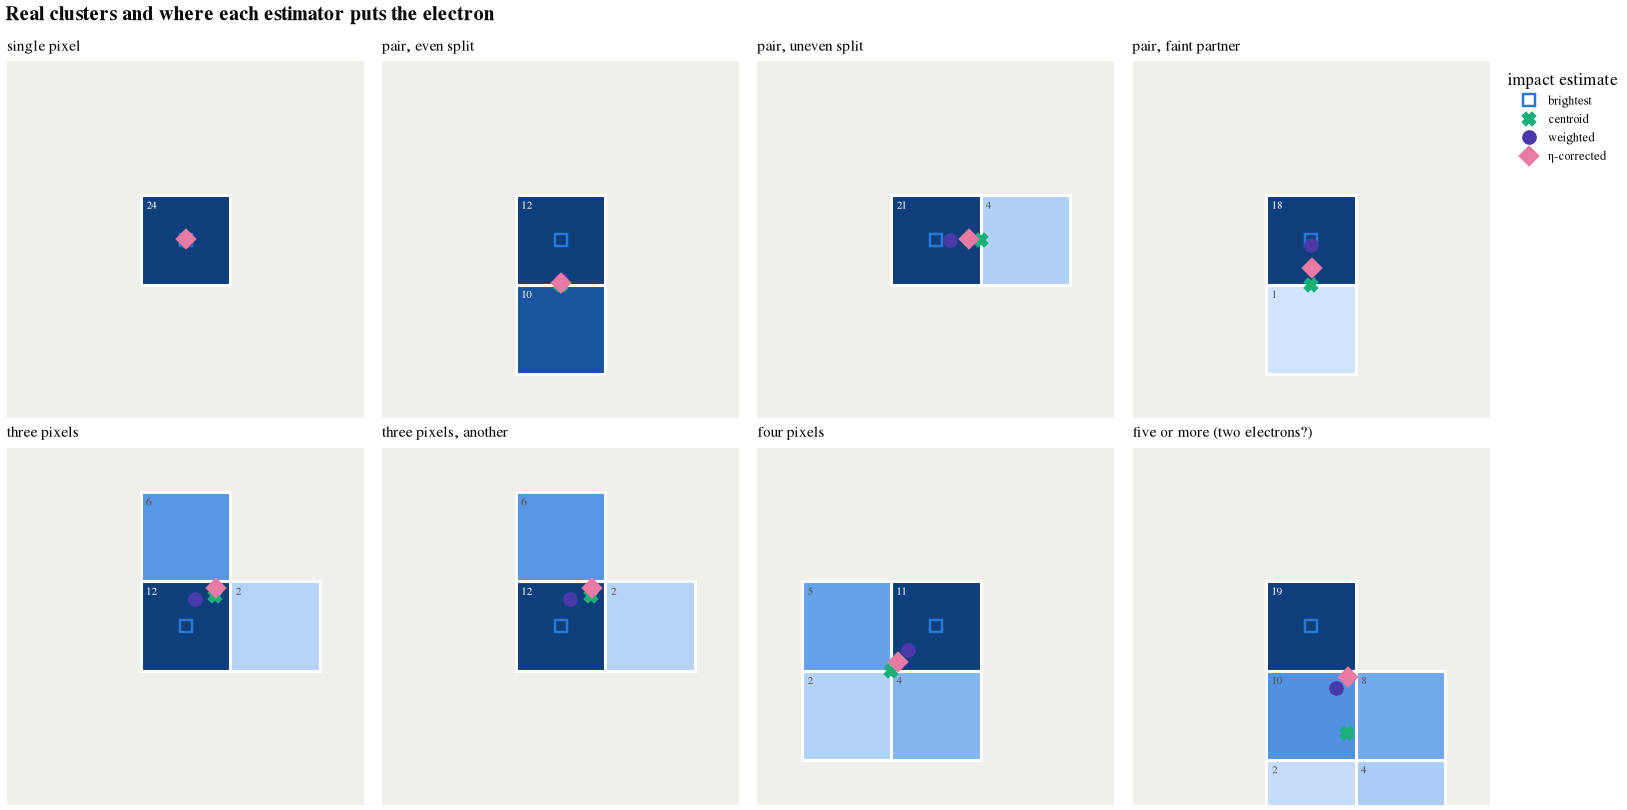

In [5]:
n_ = sample_stats.n.to_numpy()
share = 1 - sample_stats.tot_b.to_numpy() / np.maximum(sample_stats.tot.to_numpy(), 1)  # ToT outside the brightest pixel
cluster_start = np.r_[0, np.cumsum(np.bincount(sample_labels))]
event_order = np.argsort(sample_labels, kind='stable')
candidates = {
    'single pixel': np.flatnonzero(n_ == 1),
    'pair, even split': np.flatnonzero((n_ == 2) & (share > 0.42)),
    'pair, uneven split': np.flatnonzero((n_ == 2) & (share > 0.1) & (share < 0.2)),
    'pair, faint partner': np.flatnonzero((n_ == 2) & (share < 0.06)),
    'three pixels': np.flatnonzero(n_ == 3),
    'three pixels, another': np.flatnonzero(n_ == 3),
    'four pixels': np.flatnonzero(n_ == 4),
    'five or more (two electrons?)': np.flatnonzero(n_ >= 5),
}
rng = np.random.default_rng(3)
fig, axes = plt.subplots(2, 4, figsize=(15, 7.6))
for ax, (kind, ks) in zip(axes.flat, candidates.items()):
    k = rng.choice(ks)
    idx = event_order[cluster_start[k] : cluster_start[k + 1]]
    draw_pixels(
        ax,
        sample['x'][idx].astype(int),
        sample['y'][idx].astype(int),
        sample['tot'][idx],
        {name: (v[0][k], v[1][k]) for name, v in sample_impact.items()},
        (int(sample_stats.x_b[k]), int(sample_stats.y_b[k])),
    )
    ax.set_title(kind, fontsize=10)
axes[0, -1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, title='impact estimate')
fig.suptitle('Real clusters and where each estimator puts the electron', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

A single pixel says only "somewhere in this pixel", and every estimator puts it at the center. For
larger clusters `brightest` stays on a pixel center, `centroid` ignores how the charge is split,
`weighted` follows the split, and `η-corrected` moves `weighted` toward the border.

## 3. What the real data can tell: pairs

Half of all clusters are two pixels. Put every horizontal pair on a common axis (left pixel center at
0, right at 1, border at ½) and histogram where each estimator places the electron.

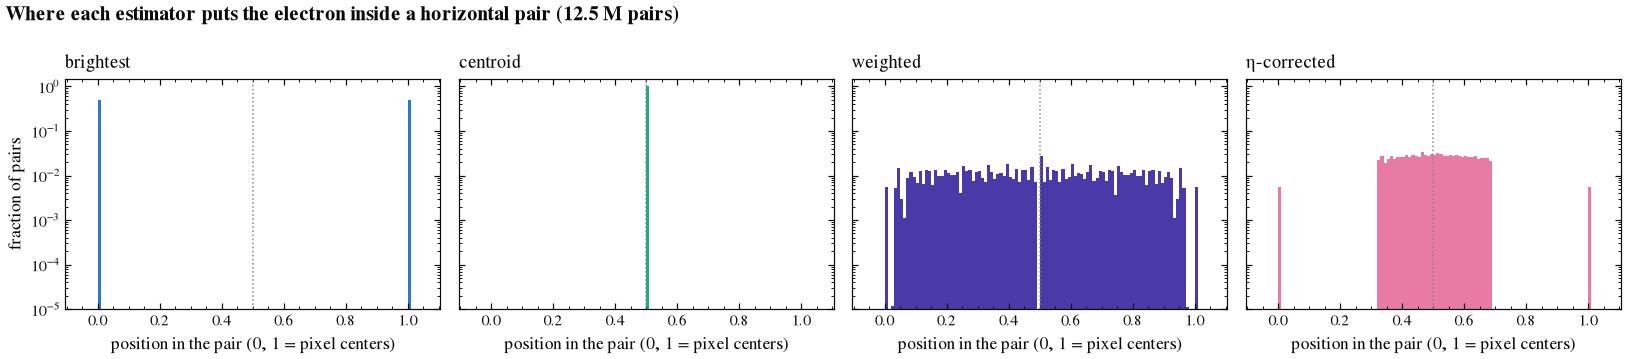

63% of clusters do not share charge along x; under even illumination that leaves strips 0.18 px (10 µm) wide on each side of a border for the rest


In [6]:
pair = ((stats.n == 2) & (stats.s_dy == 0)).to_numpy()
left = stats.x_b.to_numpy(np.float32)[pair] + np.minimum(stats.s_dx.to_numpy(np.float32)[pair], 0)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, name in zip(axes, impact):
    p = impact[name][0][pair] - left
    ax.hist(p, bins=np.linspace(-0.05, 1.05, 111), color=POSITION[name][0], weights=np.full(len(p), 1 / len(p)))
    ax.axvline(0.5, color=MUTED, lw=1, ls=':')
    ax.set(title=name, xlabel='position in the pair (0, 1 = pixel centers)', yscale='log', ylim=(1e-5, 1.5))
axes[0].set_ylabel('fraction of pairs')
fig.suptitle(
    f'Where each estimator puts the electron inside a horizontal pair ({pair.sum() / 1e6:.1f} M pairs)', x=0.01, ha='left', fontweight='bold'
)
plt.tight_layout()
plt.show()
a_x = np.mean(np.abs(subpixel(impact['weighted'][0])) < 0.02)  # clusters that do not share charge along x
print(
    f'{a_x:.0%} of clusters do not share charge along x; under even illumination that leaves strips {(1 - a_x) / 2:.2f} px ({(1 - a_x) / 2 * PIXEL_UM:.0f} µm) wide on each side of a border for the rest'
)

`brightest` and `centroid` put pairs on a few fixed points. `weighted` spreads them almost evenly over
both pixels, while `η-corrected` squeezes them into a narrow band around the border. **These two cannot
both be right.** The η argument is a counting one: under even illumination the single-pixel clusters
(37 %) must come from the middles of their pixels, since an electron near a border would share charge.
That leaves only narrow strips along the borders for pairs. `weighted` ignores this. The data cannot
settle it, because it has no ground truth.

## 4. What the real data can tell: filling the pixel

Fold every impact of the run into one pixel. Under even illumination the true impacts fill it evenly;
bright lines and dots are positions an estimator snaps to.

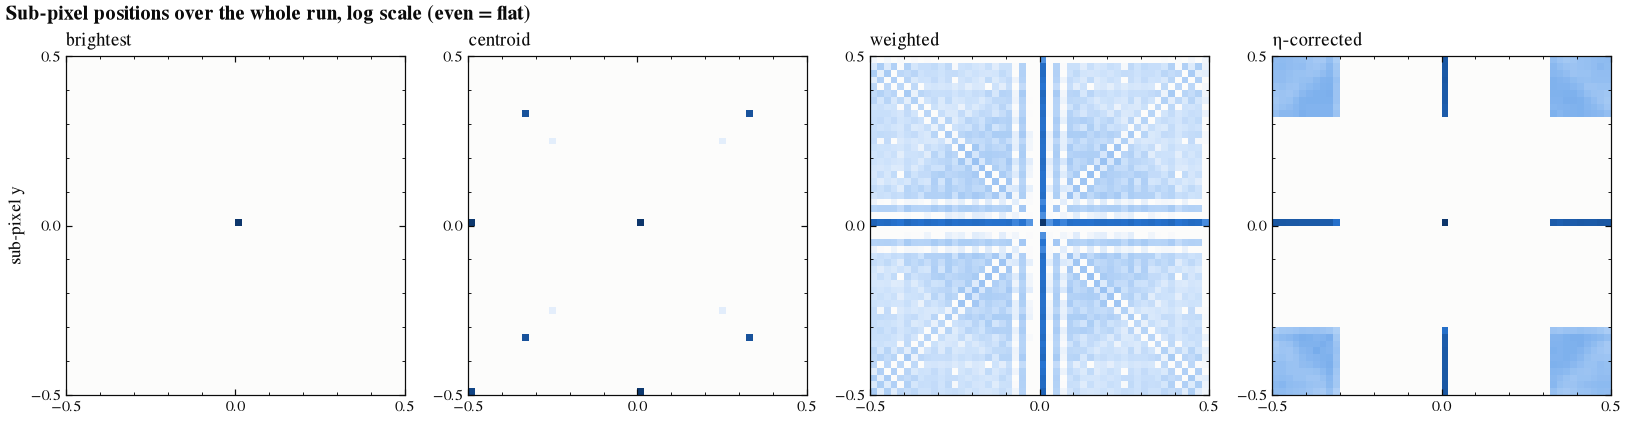

In [7]:
edges = np.linspace(-0.5, 0.5, 51)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, name in zip(axes, impact):
    h, _, _ = np.histogram2d(subpixel(impact[name][1]), subpixel(impact[name][0]), bins=(edges, edges))
    ax.imshow(np.maximum(h / h.mean(), 1e-3), origin='lower', extent=(-0.5, 0.5, -0.5, 0.5), cmap=SEQUENTIAL, norm=LogNorm(1e-2, 1e3))
    ax.set_title(name)
    ax.set_xticks([-0.5, 0, 0.5]), ax.set_yticks([-0.5, 0, 0.5])
    ax.grid(False)
axes[0].set_ylabel('sub-pixel y')
fig.suptitle('Sub-pixel positions over the whole run, log scale (even = flat)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

`brightest` puts everything at the pixel center and `centroid` snaps to a few points. `weighted` is
fairly even but has a bright cross through the middle. `η-corrected` shows the geometry the counting
argument implies (single pixels in the middle, pairs along the borders, larger clusters in the
corners), but it is even by construction, so this shows what η assumes, not that it is right.

To decide, we need clusters whose true entry point is known. That means simulating the electron.

## 5. Simulating the electron

### 5a. The physics in one figure

A 60 keV electron enters the sensor, slows down, scatters and stops. It loses energy at a rate given by
the Bethe formula (Joy–Luo form for low energies):

`dE/ds ≈ 7.85·10⁴ · ρZ/(A·E) · ln(1.166 (E + 0.85 J)/J)` keV/cm, with `J = 173 eV` for silicon.

At these energies `dE/ds` rises roughly as `1/E`: **a slow electron deposits more per µm**, so the
bright end of a cluster is where the electron stopped, not where it entered.

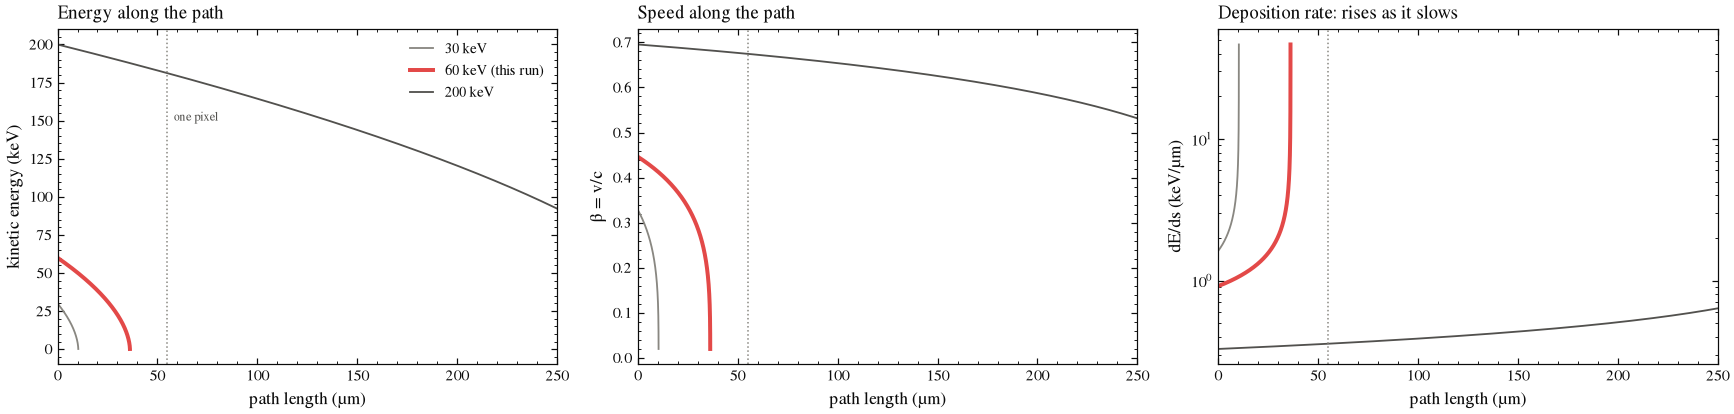

60 keV: β = 0.45, path length 36 µm (0.66 pixels); half the energy is deposited in the last 10 µm


In [8]:
Z_SI, A_SI, RHO_SI, J_SI = 14.0, 28.09, 2.33, 0.173  # -, g/mol, g/cm^3, keV
N_SI = 6.022e23 * RHO_SI / A_SI  # atoms per cm^3
MC2 = 511.0  # electron rest energy, keV


@numba.njit(cache=True)
def stopping(e):
    # Joy-Luo modified Bethe stopping power in silicon, keV per µm.
    return 78500.0 * RHO_SI * Z_SI / (A_SI * e) * math.log(1.166 * (e + 0.85 * J_SI) / J_SI) * 1e-4


@numba.njit(cache=True)
def screening(e):
    return 3.4e-3 * Z_SI**0.67 / e


@numba.njit(cache=True)
def mean_free_path(e):
    # Elastic mean free path in µm: screened Rutherford cross section with relativistic correction.
    a = screening(e)
    sigma = 5.21e-21 * (Z_SI * Z_SI / (e * e)) * (4 * math.pi / (a * (1 + a))) * ((e + MC2) / (e + 2 * MC2)) ** 2
    return 1e4 / (N_SI * sigma)


def beta(e):
    gamma = 1 + np.asarray(e) / MC2
    return np.sqrt(1 - 1 / gamma**2)


def csda_path(e0, n=2000):
    # Energy, path length (µm) and stopping power along the continuous-slowing-down path, down to 0.1 keV.
    e = np.linspace(e0, 0.1, n)
    s = np.array([stopping(v) for v in e])
    path = np.concatenate([[0], np.cumsum(-np.diff(e) * 0.5 * (1 / s[1:] + 1 / s[:-1]))])
    return e, path, s


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for e0, color, lw in ((30.0, MUTED, 1.2), (E_BEAM_KEV, RED, 2.6), (200.0, INK_2, 1.2)):
    e, path, s = csda_path(e0)
    label = f'{e0:.0f} keV' + (' (this run)' if e0 == E_BEAM_KEV else '')
    axes[0].plot(path, e, color=color, lw=lw, label=label)
    axes[1].plot(path, beta(e), color=color, lw=lw, label=label)
    axes[2].plot(path, s, color=color, lw=lw, label=label)
for ax in axes:
    ax.axvline(PIXEL_UM, color=MUTED, ls=':', lw=1)
axes[0].text(PIXEL_UM + 3, 150, 'one pixel', color=INK_2, fontsize=8)
axes[0].set(xlabel='path length (µm)', ylabel='kinetic energy (keV)', title='Energy along the path', xlim=(0, 250))
axes[1].set(xlabel='path length (µm)', ylabel='β = v/c', title='Speed along the path', xlim=(0, 250))
axes[2].set(xlabel='path length (µm)', ylabel='dE/ds (keV/µm)', title='Deposition rate: rises as it slows', xlim=(0, 250), yscale='log')
axes[0].legend()
plt.tight_layout()
plt.show()
e, path, s = csda_path(E_BEAM_KEV)
print(
    f'{E_BEAM_KEV:.0f} keV: β = {beta(E_BEAM_KEV):.2f}, path length {path[-1]:.0f} µm ({path[-1] / PIXEL_UM:.2f} pixels); half the energy is deposited in the last {path[-1] - np.interp(E_BEAM_KEV / 2, E_BEAM_KEV - e, path):.0f} µm'
)

### 5b. A Monte Carlo of electrons in silicon

The path length is not how far the electron gets: the mean free path between elastic collisions is
under 0.1 µm, so the electron scatters thousands of times. The standard single-scattering Monte Carlo
(Joy, *Monte Carlo Modeling for Electron Microscopy and Microanalysis*) follows it:

* free flights between elastic collisions, exponentially distributed with the screened-Rutherford mean
  free path, with continuous energy loss along each flight;
* at each collision, a polar angle from the screened-Rutherford distribution and a uniform azimuth;
* the beam enters at normal incidence; electrons that come back out are **backscattered** and take
  their remaining energy with them.

Each electron's deposited energy is binned at 1/8 pixel around its entry point, and each electron gets
its own random stream, so the results are reproducible.

120,000 electrons in 1.0 s
backscattered: 17.4% of electrons, carrying 10.8% of the energy (measured for silicon at tens of keV: ~15–18 % of electrons)


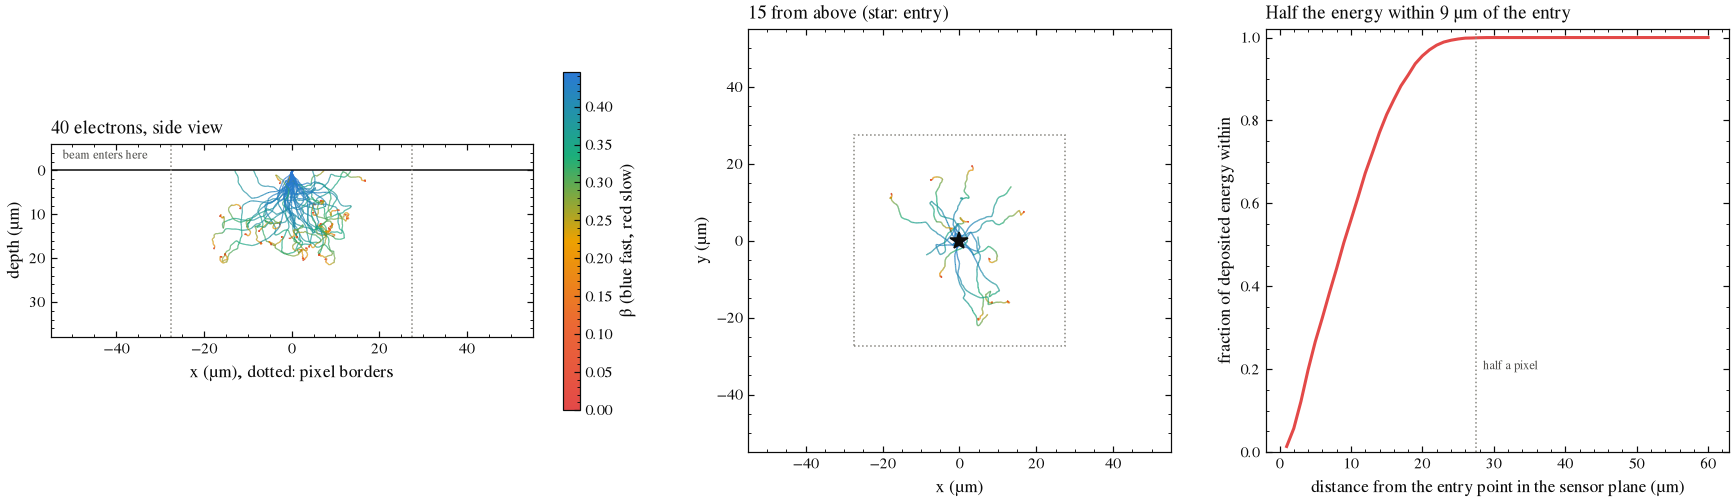

In [9]:
@numba.njit(cache=True)
def _uniform(state):
    # splitmix64 random numbers in (0, 1): one independent stream per electron.
    state[0] = (state[0] + np.uint64(0x9E3779B97F4A7C15)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    z = state[0]
    z = ((z ^ (z >> np.uint64(30))) * np.uint64(0xBF58476D1CE4E5B9)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    z = ((z ^ (z >> np.uint64(27))) * np.uint64(0x94D049BB133111EB)) & np.uint64(0xFFFFFFFFFFFFFFFF)
    z = z ^ (z >> np.uint64(31))
    return (z >> np.uint64(11)) * (1.0 / 9007199254740992.0) + 1e-17


@numba.njit(cache=True)
def _scatter(u, v, w, e, state):
    # New direction after one elastic collision (screened Rutherford polar angle, uniform azimuth).
    a = screening(e)
    r = _uniform(state)
    cos_t = 1 - 2 * a * r / (1 + a - r)
    sin_t = math.sqrt(max(0.0, 1 - cos_t * cos_t))
    phi = 2 * math.pi * _uniform(state)
    cp, sp = math.cos(phi), math.sin(phi)
    if abs(w) > 0.99999:
        nu, nv, nw = sin_t * cp, sin_t * sp, cos_t * (1.0 if w > 0 else -1.0)
    else:
        root = math.sqrt(1 - w * w)
        nu = u * cos_t + sin_t * (u * w * cp - v * sp) / root
        nv = v * cos_t + sin_t * (v * w * cp + u * sp) / root
        nw = w * cos_t - sin_t * cp * root
    norm = math.sqrt(nu * nu + nv * nv + nw * nw)
    return nu / norm, nv / norm, nw / norm


@numba.njit(cache=True)
def trajectory(e0, x0_um, y0_um, seed, e_min=0.5, max_steps=200_000):
    # One electron: positions (µm) after each flight and the energy left there; ends at e_min or on backscatter.
    state = np.array([np.uint64(seed)], dtype=np.uint64)
    xyz = np.empty((max_steps, 3))
    energy = np.empty(max_steps)
    x, y, z, u, v, w, e = x0_um, y0_um, 0.0, 0.0, 0.0, 1.0, e0
    xyz[0] = (x, y, z)
    energy[0] = e
    k = 1
    while e > e_min and k < max_steps:
        step = -mean_free_path(e) * math.log(_uniform(state))
        de = min(stopping(e) * step, e)
        nz = z + step * w
        if nz < 0:  # leaves through the entry surface
            f = z / (z - nz)
            xyz[k] = (x + f * step * u, y + f * step * v, 0.0)
            energy[k] = e - de * f
            k += 1
            break
        x, y, z, e = x + step * u, y + step * v, nz, e - de
        xyz[k] = (x, y, z)
        energy[k] = e
        k += 1
        u, v, w = _scatter(u, v, w, max(e, e_min), state)
    return xyz[:k], energy[:k]


@numba.njit(parallel=True, cache=True)
def simulate(e0, x0, y0, seed, pitch, sub, half=2, e_min=0.5):
    # Deposited energy of each electron binned at 1/sub pixel over (2*half+1)^2 pixels around its entry
    # pixel (center at 0), and the energy each one carries back out (backscatter).
    n = len(x0)
    nb = (2 * half + 1) * sub
    hist = np.zeros((n, nb, nb), np.float32)
    escaped = np.zeros(n)
    for i in numba.prange(n):
        state = np.array([np.uint64(seed) * np.uint64(1000003) + np.uint64(i)], dtype=np.uint64)
        x, y, z = x0[i] * pitch, y0[i] * pitch, 0.0
        u, v, w, e = 0.0, 0.0, 1.0, e0
        while e > e_min:
            step = -mean_free_path(e) * math.log(_uniform(state))
            de = min(stopping(e) * step, e)
            nz = z + step * w
            f = z / (z - nz) if nz < 0 else 1.0  # fraction of the flight inside the sensor
            mx, my = x + 0.5 * f * step * u, y + 0.5 * f * step * v
            bx, by = int((mx / pitch + half + 0.5) * sub), int((my / pitch + half + 0.5) * sub)
            if 0 <= bx < nb and 0 <= by < nb:
                hist[i, by, bx] += de * f
            if nz < 0:
                escaped[i] = e - de * f
                e = 0.0
                break
            x, y, z, e = x + step * u, y + step * v, nz, e - de
            u, v, w = _scatter(u, v, w, max(e, e_min), state)
        if e > 0:  # the rest stays where the electron stops
            bx, by = int((x / pitch + half + 0.5) * sub), int((y / pitch + half + 0.5) * sub)
            if 0 <= bx < nb and 0 <= by < nb:
                hist[i, by, bx] += e
    return hist, escaped


SUB = 8  # deposit bins per pixel
N_SIM = 120_000
rng = np.random.default_rng(0)
true_x, true_y = rng.uniform(-0.5, 0.5, N_SIM), rng.uniform(-0.5, 0.5, N_SIM)  # entry points, even illumination of the central pixel
start = time.perf_counter()
deposit, escaped = simulate(E_BEAM_KEV, true_x, true_y, 1, PIXEL_UM, SUB)
print(f'{N_SIM:,} electrons in {time.perf_counter() - start:.1f} s')
print(
    f'backscattered: {np.mean(escaped > 0):.1%} of electrons, carrying {escaped.sum() / (N_SIM * E_BEAM_KEV):.1%} of the energy (measured for silicon at tens of keV: ~15–18 % of electrons)'
)

SPEED = LinearSegmentedColormap.from_list('speed', [RED, ORANGE, YELLOW, AQUA, BLUE])  # slow -> fast


def colored_path(ax, a, b, energy, lw=1.0):
    # A track as line segments colored by the electron's speed.
    points = np.c_[a, b][:, None, :]
    lines = LineCollection(np.concatenate([points[:-1], points[1:]], axis=1), cmap=SPEED, norm=Normalize(0, beta(E_BEAM_KEV)), linewidths=lw)
    lines.set_array(beta(energy[:-1]))
    ax.add_collection(lines)
    return lines


fig, (ax_side, ax_top, ax_radial) = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={'width_ratios': [1.3, 1, 1]})
for seed in range(40):
    xyz, energy = trajectory(E_BEAM_KEV, 0.0, 0.0, 100 + seed)
    lines = colored_path(ax_side, xyz[:, 0], xyz[:, 2], energy, 0.7)
    if seed < 15:
        colored_path(ax_top, xyz[:, 0], xyz[:, 1], energy, 0.8)
for ax in (ax_side, ax_top):
    ax.grid(False)
ax_side.axhline(0, color=INK, lw=1)
ax_side.text(-PIXEL_UM * 0.95, -2, 'beam enters here', fontsize=8, color=INK_2, va='bottom')
for edge in (-PIXEL_UM / 2, PIXEL_UM / 2):
    ax_side.axvline(edge, color=MUTED, ls=':', lw=1)
ax_side.set(
    xlim=(-PIXEL_UM, PIXEL_UM),
    ylim=(path[-1] * 1.05, -6),
    aspect='equal',
    xlabel='x (µm), dotted: pixel borders',
    ylabel='depth (µm)',
    title='40 electrons, side view',
)
fig.colorbar(lines, ax=ax_side, label='β (blue fast, red slow)', shrink=0.8)
ax_top.add_patch(Rectangle((-PIXEL_UM / 2, -PIXEL_UM / 2), PIXEL_UM, PIXEL_UM, fill=False, ec=MUTED, ls=':'))
ax_top.plot(0, 0, marker='*', color=INK, ms=12)
ax_top.set(
    xlim=(-PIXEL_UM, PIXEL_UM), ylim=(-PIXEL_UM, PIXEL_UM), aspect='equal', xlabel='x (µm)', ylabel='y (µm)', title='15 from above (star: entry)'
)
centers = ((np.arange(deposit.shape[1]) + 0.5) / SUB - 2.5) * PIXEL_UM
r_edges = np.linspace(0, 60, 61)
radial = np.zeros(60)
for i in range(2000):
    gx, gy = np.meshgrid(centers - true_x[i] * PIXEL_UM, centers - true_y[i] * PIXEL_UM)
    radial += np.histogram(np.hypot(gx, gy), r_edges, weights=deposit[i])[0]
cumulative = np.cumsum(radial) / radial.sum()
ax_radial.plot(r_edges[1:], cumulative, color=RED, lw=2)
ax_radial.axvline(PIXEL_UM / 2, color=MUTED, ls=':', lw=1)
ax_radial.text(PIXEL_UM / 2 + 1, 0.2, 'half a pixel', fontsize=8, color=INK_2)
ax_radial.set(
    xlabel='distance from the entry point in the sensor plane (µm)',
    ylabel='fraction of deposited energy within',
    ylim=(0, 1.02),
    title=f'Half the energy within {np.interp(0.5, cumulative, r_edges[1:]):.0f} µm of the entry',
)
plt.tight_layout()
plt.show()

The electron dives in, scatters, and wanders, and its slow, bright end lies some µm away from where it
entered, mostly within a fraction of a pixel. The backscatter fraction agrees with measured values for
silicon, a check on the elastic scattering.

## 6. Fit the detector response to the real clusters

The simulation gives deposited energy; the detector turns it into pixel ToT. Three unknowns:

* **`σ_d`**: diffusion of the charge cloud while it drifts to the pixels (a Gaussian, in pixels);
* **`threshold`** (keV): pixels with less deposited energy do not fire;
* **ToT scale**: `ToT = ⌈(E − threshold)/gain + offset⌉`. The gain is set so single-pixel clusters have
  the measured median summed ToT; the offset lets pairs carry slightly more summed ToT than singles, as
  they do in the data.

All 624 combinations on a grid are scored against four things the real cluster sums hold: the
fractions of 1-, 2-, 3- and 4+-pixel clusters, the distribution of the ToT split in pairs, and the
summed-ToT difference between pairs and single pixels.

624 detector models in 62 s; best: σ_d = 0.18 px (10 µm), threshold 8 keV, 2.09 keV per ToT, offset 1.5
(diffusion through 300 µm at 100 V would give σ ≈ 0.12 px)


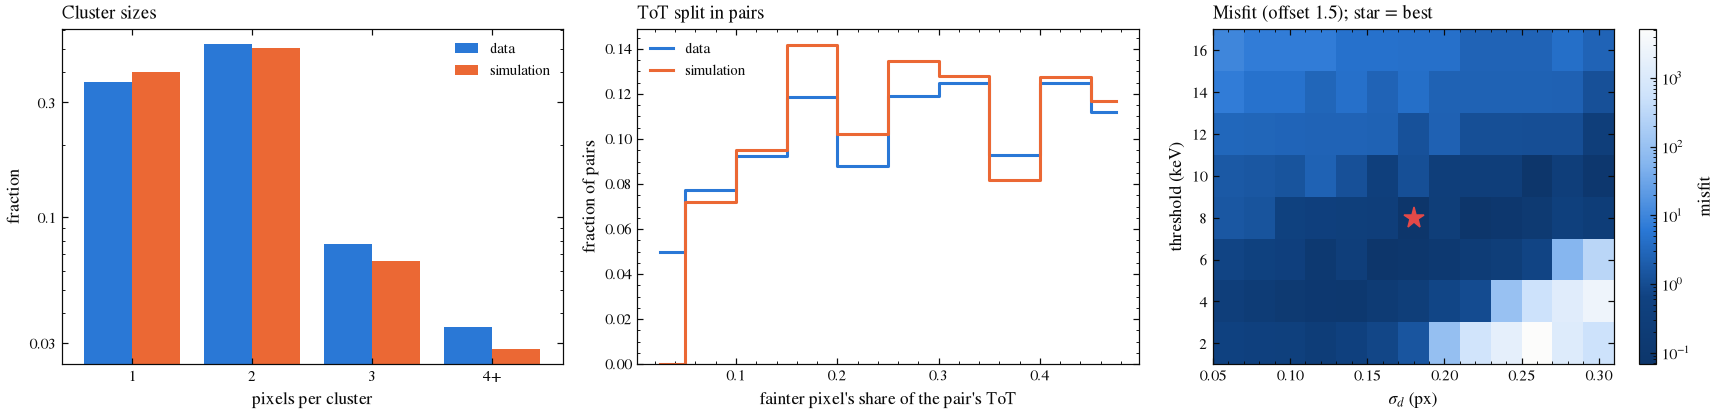

In [10]:
def diffuse(hist, sigma_px, sub, half=2):
    # Charge per pixel after Gaussian diffusion of width sigma_px: separable, one matrix per axis.
    side = 2 * half + 1
    bin_centers = (np.arange(side * sub) + 0.5) / sub - half - 0.5
    pixel_edges = np.arange(side + 1) - half - 0.5
    cdf = 0.5 * (1 + erf((pixel_edges[None, :] - bin_centers[:, None]) / (np.sqrt(2) * sigma_px)))
    share = np.diff(cdf, axis=1).astype(np.float32)  # (bins, pixels)
    return np.einsum('nyx,yj,xi->nji', hist, share, share, optimize=True)


def response(energy, threshold, gain, offset):
    # Pixel ToT from deposited energy (keV); -1 where the pixel does not fire.
    return np.where(energy >= threshold, np.maximum(np.ceil((energy - threshold) / gain + offset), 0), -1)


G = np.arange(5) - 2
GX, GY = np.meshgrid(G, G)


def image_sums(tot):
    # The cluster-sum table of section 1 for simulated 5x5 ToT images (-1 = no hit), drops empty images.
    hit = tot >= 0
    keep = hit.any((1, 2))
    tot, hit = tot[keep], hit[keep]
    q = np.where(hit, tot, 0)
    b = np.where(hit, tot, -1).reshape(len(tot), -1).argmax(1)
    bx, by = GX.ravel()[b], GY.ravel()[b]
    dx, dy = GX[None] - bx[:, None, None], GY[None] - by[:, None, None]
    table = pd.DataFrame(
        {
            'n': hit.sum((1, 2)),
            'tot': q.sum((1, 2)),
            'x_b': bx,
            'y_b': by,
            'tot_b': q.max((1, 2)),
            's_dx': (hit * dx).sum((1, 2)),
            's_dy': (hit * dy).sum((1, 2)),
            'w_dx': (q * dx).sum((1, 2)),
            'w_dy': (q * dy).sum((1, 2)),
        }
    )
    return table, keep


def observables(table):
    # Size fractions, ToT-split histogram of pairs, median summed ToT of singles and of pairs.
    n, total, split_bins = table.n.to_numpy(), table.tot.to_numpy(), np.linspace(0, 0.5, 11)
    pair = n == 2
    split = np.histogram(1 - table.tot_b.to_numpy()[pair] / np.maximum(total[pair], 1), split_bins)[0]
    return np.bincount(np.minimum(n, 4), minlength=5)[1:5] / len(n), split / split.sum(), np.median(total[n == 1]), np.median(total[pair])


data_obs = observables(stats)
N_FIT = 60_000
SIGMAS = [0.06, 0.08, 0.10, 0.12, 0.14, 0.16, 0.18, 0.20, 0.22, 0.24, 0.26, 0.28, 0.30]
THRESHOLDS = [2, 4, 6, 8, 10, 12, 14, 16]
OFFSETS = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
rows = []
start = time.perf_counter()
for sigma in SIGMAS:
    energy = diffuse(deposit[:N_FIT], sigma, SUB)
    for threshold in THRESHOLDS:
        for offset in OFFSETS:
            gain = (E_BEAM_KEV - threshold) / (data_obs[2] - offset)
            for _ in range(4):  # adjust the gain until single pixels have the data's median summed ToT
                table, _ = image_sums(response(energy, threshold, gain, offset))
                gain *= (np.median(table.tot[table.n == 1]) - offset) / (data_obs[2] - offset)
            sizes, split, med1, med2 = observables(image_sums(response(energy, threshold, gain, offset))[0])
            d_sizes = np.sum((sizes - data_obs[0]) ** 2 / data_obs[0])
            d_split = np.sum((split - data_obs[1]) ** 2 / data_obs[1])
            d_tot = ((med2 - med1) - (data_obs[3] - data_obs[2])) ** 2 / 4
            rows.append({'sigma_px': sigma, 'threshold_keV': threshold, 'offset': offset, 'gain_keV': gain, 'misfit': d_sizes + d_split + d_tot})
grid = pd.DataFrame(rows).sort_values('misfit')
best = grid.iloc[0]
print(
    f'{len(grid)} detector models in {time.perf_counter() - start:.0f} s; best: σ_d = {best.sigma_px:.2f} px ({best.sigma_px * PIXEL_UM:.0f} µm), threshold {best.threshold_keV:.0f} keV, {best.gain_keV:.2f} keV per ToT, offset {best.offset}'
)
print(f'(diffusion through {SENSOR_UM:.0f} µm at {BIAS_V:.0f} V would give σ ≈ {SENSOR_UM * np.sqrt(2 * 0.02585 / BIAS_V) / PIXEL_UM:.2f} px)')

sim_tot = response(diffuse(deposit, best.sigma_px, SUB), best.threshold_keV, best.gain_keV, best.offset)
sim, sim_keep = image_sums(sim_tot)
sim_obs = observables(sim)
true_x, true_y, escaped, sim_tot = true_x[sim_keep], true_y[sim_keep], escaped[sim_keep], sim_tot[sim_keep]

fig, (ax_sizes, ax_split, ax_land) = plt.subplots(1, 3, figsize=(16, 4))
ax_sizes.bar(np.arange(4) - 0.2, data_obs[0], 0.4, color=BLUE, label='data')
ax_sizes.bar(np.arange(4) + 0.2, sim_obs[0], 0.4, color=ORANGE, label='simulation')
ax_sizes.set(xticks=range(4), xticklabels=['1', '2', '3', '4+'], xlabel='pixels per cluster', ylabel='fraction', yscale='log', title='Cluster sizes')
ax_sizes.xaxis.minorticks_off()
ax_sizes.set_yticks([0.03, 0.1, 0.3], ['0.03', '0.1', '0.3'])  # less than a decade: plain labels
ax_sizes.tick_params(axis='y', which='minor', labelleft=False)
ax_sizes.legend()
mid = np.linspace(0.025, 0.475, 10)
ax_split.step(mid, data_obs[1], where='mid', color=BLUE, lw=2, label='data')
ax_split.step(mid, sim_obs[1], where='mid', color=ORANGE, lw=2, label='simulation')
ax_split.set(xlabel="fainter pixel's share of the pair's ToT", ylabel='fraction of pairs', ylim=(0, None), title='ToT split in pairs')
ax_split.legend()
land = grid[grid.offset == best.offset].pivot(index='threshold_keV', columns='sigma_px', values='misfit')
shown = ax_land.imshow(
    land.to_numpy(),
    origin='lower',
    cmap=SEQUENTIAL.reversed(),
    aspect='auto',
    norm=LogNorm(),
    extent=(SIGMAS[0] - 0.01, SIGMAS[-1] + 0.01, -0.5, len(THRESHOLDS) - 0.5),
)
ax_land.set_yticks(range(len(THRESHOLDS)), THRESHOLDS)
ax_land.plot(best.sigma_px, THRESHOLDS.index(best.threshold_keV), marker='*', color=RED, ms=14)
ax_land.yaxis.minorticks_off()
ax_land.set(xlabel=r'$\sigma_d$ (px)', ylabel='threshold (keV)', title=f'Misfit (offset {best.offset}); star = best')
ax_land.grid(False)
fig.colorbar(shown, ax=ax_land, label='misfit')
plt.tight_layout()
plt.show()

The fitted model reproduces the size mix and the ToT split of the real clusters. The misfit map is a
valley, not a point (more diffusion trades against a higher threshold), so section 7 checks that the
conclusions hold along the valley. One mismatch remains: the data has some pairs with an almost empty
partner (split < 0.05) that the model does not make. Those are ToT-0 and ToT-1 pixels, where the real
ToT is not linear in energy.

## 7. Where did the electron enter?

Every simulated cluster now has the same sums as a real one, and a known entry point. Score each
estimator by its distance to the true entry (per axis, RMS), learning on one half of the simulation
and testing on the other.

### 7a. What the simulation says

Describe a multi-pixel cluster by **u**, the ToT-weighted offset from its brightest pixel, and ask how
far along **u** the true entry lies. Entry exactly at `weighted` would follow the dashed diagonal.

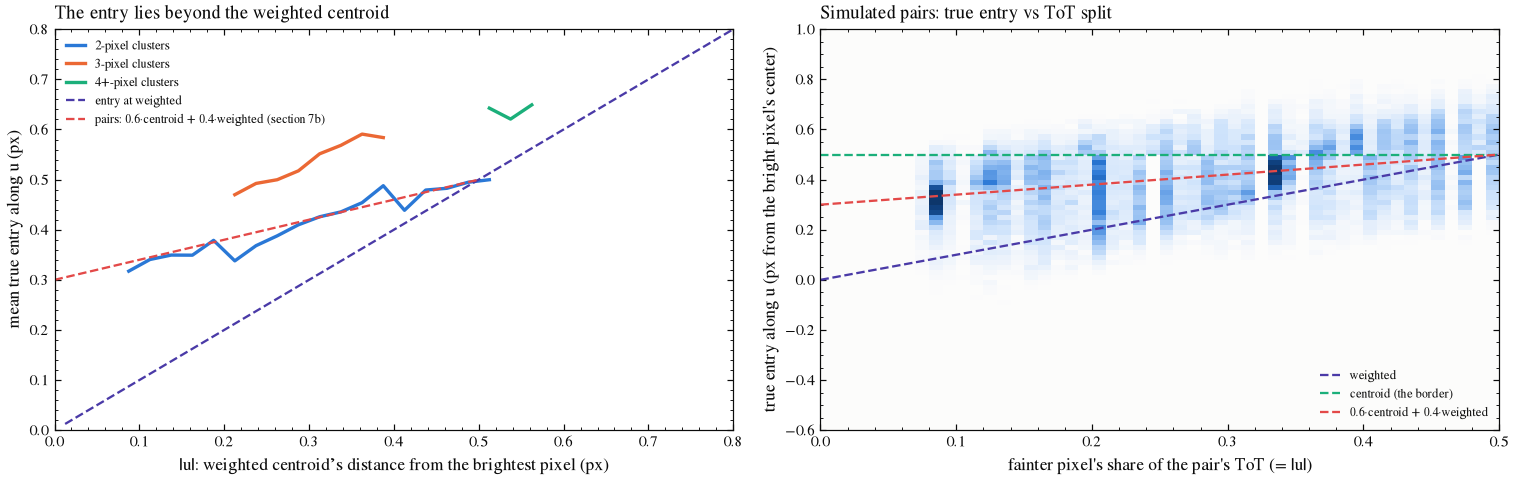

In [11]:
sim_impact = positions(sim)
train = np.arange(len(sim)) < len(sim) // 2
test = ~train
sim_impact['η-corrected'] = tuple(apply_eta(v, np.sort(subpixel(v[train]))) for v in sim_impact['weighted'])
sim_n = sim.n.to_numpy()
bx, by = sim.x_b.to_numpy(float), sim.y_b.to_numpy(float)
ux, uy = sim_impact['weighted'][0] - bx, sim_impact['weighted'][1] - by
mag = np.hypot(ux, uy)
along = ((true_x - bx) * ux + (true_y - by) * uy) / np.maximum(mag, 1e-9)  # true entry along u, from the brightest pixel
U_BINS = np.linspace(0, 1.0, 41)
u_mid = (U_BINS[1:] + U_BINS[:-1]) / 2


def rms_error(px, py, mask):
    return np.sqrt(np.mean(((px - true_x) ** 2 + (py - true_y) ** 2)[mask]) / 2)  # per axis, pixels


fig, (ax_g, ax_pair) = plt.subplots(1, 2, figsize=(14, 4.6))
for c, color in ((2, BLUE), (3, ORANGE), (4, AQUA)):
    sel = train & (np.minimum(sim_n, 4) == c) & (mag > 1e-6)
    idx = np.digitize(mag[sel], U_BINS) - 1
    counts = np.bincount(idx, minlength=len(u_mid))[: len(u_mid)]
    mean_along = np.bincount(idx, along[sel], minlength=len(u_mid))[: len(u_mid)] / np.maximum(counts, 1)
    ax_g.plot(u_mid[counts >= 200], mean_along[counts >= 200], color=color, lw=2.2, label=f'{c}{"+" if c == 4 else ""}-pixel clusters')
ax_g.plot(u_mid, u_mid, color=VIOLET, ls='--', lw=1.5, label='entry at weighted')
ax_g.plot([0, 0.5], [0.3, 0.5], color=RED, ls='--', lw=1.5, label='pairs: 0.6·centroid + 0.4·weighted (section 7b)')
ax_g.set(
    xlabel='|u|: weighted centroid’s distance from the brightest pixel (px)',
    ylabel='mean true entry along u (px)',
    xlim=(0, 0.8),
    ylim=(0, 0.8),
    title='The entry lies beyond the weighted centroid',
)
ax_g.legend(fontsize=8)
pair = test & (sim_n == 2)
h, xe, ye = np.histogram2d(mag[pair], along[pair], bins=(np.linspace(0, 0.5, 51), np.linspace(-0.6, 1.0, 81)))
ax_pair.imshow(h.T, origin='lower', aspect='auto', cmap=SEQUENTIAL, extent=(0, 0.5, -0.6, 1.0))
ax_pair.plot([0, 0.5], [0, 0.5], color=VIOLET, ls='--', lw=1.5, label='weighted')
ax_pair.plot([0, 0.5], [0.5, 0.5], color=AQUA, ls='--', lw=1.5, label='centroid (the border)')
ax_pair.plot([0, 0.5], [0.3, 0.5], color=RED, ls='--', lw=1.5, label='0.6·centroid + 0.4·weighted')
ax_pair.set(
    xlabel="fainter pixel's share of the pair's ToT (= |u|)",
    ylabel="true entry along u (px from the bright pixel's center)",
    title='Simulated pairs: true entry vs ToT split',
)
ax_pair.legend(fontsize=8, loc='lower right')
ax_pair.grid(False)
plt.tight_layout()
plt.show()

For pairs, even when the fainter pixel holds only a few % of the ToT, the electron entered ~0.3 px from
the bright pixel's center, out toward the border, and as the split evens out the entry moves to the
border. `weighted` (dashed violet) puts uneven pairs much too close to the bright pixel's center;
`centroid` (dashed aqua) puts every pair on the border, too far. The truth lies in between, as the
counting argument of section 3 suggested. The physics: the electron enters, travels, and dumps most of
its energy at its slow end, in the bright pixel. The scatter around the trend (right) is the electron's
random walk, which no estimator can recover from the pixel sums.

### 7b. A simple model for the best centroid

The best possible position estimate from these sums is the average true entry for clusters that look
alike, a large lookup table. Is there a simple rule that does as well? Fit the most general linear
combination of what the standard estimators offer, offsets from the brightest pixel:

`entry − brightest ≈ α_c·(centroid − brightest) + α_w·(weighted − brightest) + β·û`

(`û` is the unit vector along **u**, a fixed step toward the fainter side.) Least squares on the training
half:

entry - brightest ≈ 0.554·(centroid - brightest) + 0.467·(weighted - brightest) + 0.012·û
α_c + α_w = 1.021 and β ≈ 0: the fit is an average of centroid and weighted. One parameter, λ = 0.60, minimizes the error on the test half.


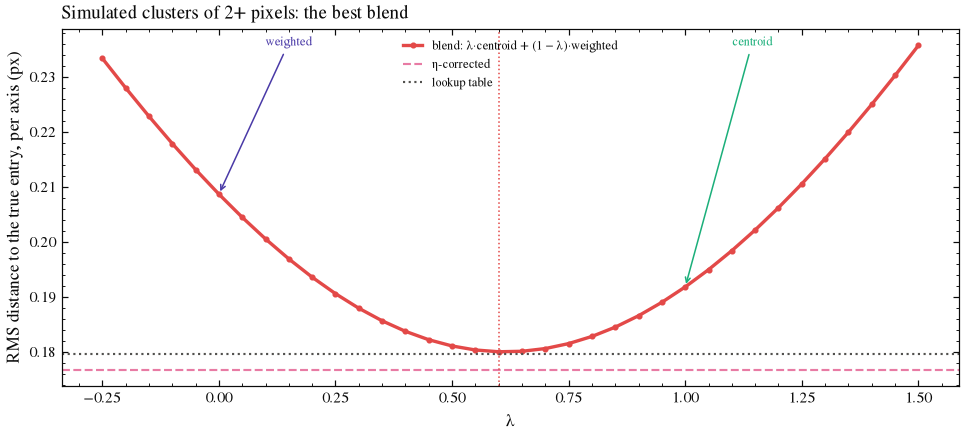

,all clusters (px),single pixels (px),pairs (px),3+ pixels (px),all (µm)
estimator,,,,,
brightest,0.311888,0.222929,0.343407,0.432246,17.2
centroid,0.204782,0.222929,0.199831,0.141434,11.3
weighted,0.214477,0.222929,0.208513,0.209653,11.8
η-corrected,0.196448,0.222961,0.184490,0.127288,10.8
blend,0.198235,0.222929,0.184392,0.154607,10.9
lookup table,0.198045,0.222929,0.184078,0.154035,10.9


In [12]:
multi = sim_n >= 2
ex, ey = ux / np.maximum(mag, 1e-9), uy / np.maximum(mag, 1e-9)
cx, cy = sim_impact['centroid'][0] - bx, sim_impact['centroid'][1] - by
fit = train & multi & (mag > 1e-6)
features = np.r_[np.c_[cx[fit], ux[fit], ex[fit]], np.c_[cy[fit], uy[fit], ey[fit]]]
alpha_c, alpha_w, beta_step = np.linalg.lstsq(features, np.r_[true_x[fit] - bx[fit], true_y[fit] - by[fit]], rcond=None)[0]
print(f'entry - brightest ≈ {alpha_c:.3f}·(centroid - brightest) + {alpha_w:.3f}·(weighted - brightest) + {beta_step:.3f}·û')


def blend(impacts, lam):
    # lam·centroid + (1 - lam)·weighted
    return tuple(lam * c + (1 - lam) * w for c, w in zip(impacts['centroid'], impacts['weighted']))


LAMBDAS = np.round(np.arange(-0.25, 1.51, 0.05), 3)
sim_lam = np.array([rms_error(*blend(sim_impact, lam), test & multi) for lam in LAMBDAS])
LAMBDA = LAMBDAS[np.argmin(sim_lam)]
sim_impact['blend'] = blend(sim_impact, LAMBDA)
print(
    f'α_c + α_w = {alpha_c + alpha_w:.3f} and β ≈ 0: the fit is an average of centroid and weighted. One parameter, λ = {LAMBDA:.2f}, minimizes the error on the test half.'
)

# The lookup table, for comparison: mean entry along u per size class and |u| bin, learned on the training half.
table = np.zeros((5, len(u_mid)))
for c in (2, 3, 4):
    sel = train & (np.minimum(sim_n, 4) == c) & (mag > 1e-6)
    idx = np.digitize(mag[sel], U_BINS) - 1
    counts = np.bincount(idx, minlength=len(u_mid))[: len(u_mid)]
    sums = np.bincount(idx, along[sel], minlength=len(u_mid))[: len(u_mid)]
    good = counts >= 200
    table[c] = np.interp(u_mid, u_mid[good], sums[good] / counts[good])
g = np.where(mag > 1e-6, table[np.minimum(sim_n, 4), np.clip(np.digitize(mag, U_BINS) - 1, 0, len(u_mid) - 1)], 0)
lookup = (bx + g * ex, by + g * ey)

rows = []
for name, (px, py) in {**sim_impact, 'lookup table': lookup}.items():
    rows.append(
        {
            'estimator': name,
            'all clusters (px)': rms_error(px, py, test),
            'single pixels (px)': rms_error(px, py, test & (sim_n == 1)),
            'pairs (px)': rms_error(px, py, test & (sim_n == 2)),
            '3+ pixels (px)': rms_error(px, py, test & (sim_n >= 3)),
            'all (µm)': rms_error(px, py, test) * PIXEL_UM,
        }
    )
sim_table = pd.DataFrame(rows).set_index('estimator')

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(LAMBDAS, sim_lam, color=RED, lw=2.2, marker='o', ms=3, label='blend: λ·centroid + (1 − λ)·weighted')
for name, ls in (('η-corrected', '--'), ('lookup table', ':')):
    ax.axhline(
        rms_error(*({**sim_impact, 'lookup table': lookup}[name]), test & multi),
        color=MAGENTA if name == 'η-corrected' else INK_2,
        ls=ls,
        lw=1.4,
        label=name,
    )
ax.axvline(LAMBDA, color=RED, ls=':', lw=1)
ax.annotate(
    'weighted', (0, sim_lam[LAMBDAS == 0][0]), (0.1, sim_lam.max()), fontsize=8, color=VIOLET, arrowprops={'arrowstyle': '->', 'color': VIOLET}
)
ax.annotate('centroid', (1, sim_lam[LAMBDAS == 1][0]), (1.1, sim_lam.max()), fontsize=8, color=AQUA, arrowprops={'arrowstyle': '->', 'color': AQUA})
ax.set(xlabel='λ', ylabel='RMS distance to the true entry, per axis (px)', title='Simulated clusters of 2+ pixels: the best blend')
ax.legend(fontsize=8, loc='upper center')
plt.tight_layout()
plt.show()
sim_table.style.format('{:.3f}').format({'all (µm)': '{:.1f}'})

**The best simple centroid is an average of the two standard ones.** The free fit puts 0.55 on
`centroid` and 0.47 on `weighted` and wants no extra step (β ≈ 0.01). The weights sum to 1, so it
collapses to one parameter:

> **`blend = λ·centroid + (1 − λ)·weighted`, with λ ≈ 0.6.**

For a pair this places the electron at `0.3 + 0.4·(partner's ToT share)` pixels from the bright
pixel's center: from 0.3 px for a faint partner out to the border for an even split (red dashed lines
in 7a). On held-out electrons it does as well as the full lookup table (0.198 px per axis over all
clusters), and better than `weighted` (0.214 px) and `centroid` (0.205 px). `η-corrected` is a little
better on 3+ pixel clusters, but it needs a distribution measured on each dataset; the blend is one
fixed number computed from two sums Kronos can store. Single pixels (37 % of clusters) carry no
sub-pixel information and set a floor of 0.22 px for every estimator.

**Does λ depend on the detector fit?** Redo it for the eight best detector models along the misfit
valley (60 000 electrons each):

In [13]:
check = []
half_fit = np.arange(N_FIT) < N_FIT // 2
for _, model in grid.head(8).iterrows():
    table_m, keep_m = image_sums(response(diffuse(deposit[:N_FIT], model.sigma_px, SUB), model.threshold_keV, model.gain_keV, model.offset))
    tx, ty = np.random.default_rng(0).uniform(-0.5, 0.5, (2, N_SIM))[:, :N_FIT][:, keep_m]
    hold = ~half_fit[keep_m] & (table_m.n.to_numpy() >= 2)
    impacts_m = positions(table_m)
    errors = [np.sqrt(np.mean(((blend(impacts_m, lam)[0] - tx) ** 2 + (blend(impacts_m, lam)[1] - ty) ** 2)[hold]) / 2) for lam in LAMBDAS]
    check.append(
        {
            'σ_d (px)': model.sigma_px,
            'threshold (keV)': model.threshold_keV,
            'offset': model.offset,
            'best λ': LAMBDAS[np.argmin(errors)],
            'weighted (px)': errors[list(LAMBDAS).index(0)],
            'best blend (px)': min(errors),
        }
    )
del deposit
pd.DataFrame(check).style.format('{:.3f}').format({'σ_d (px)': '{:.2f}', 'threshold (keV)': '{:.0f}', 'offset': '{:.1f}', 'best λ': '{:.2f}'})

,σ_d (px),threshold (keV),offset,best λ,weighted (px),best blend (px)
0,0.18,8,1.5,0.60,0.208433,0.179581
1,0.26,10,1.5,0.55,0.198556,0.177334
2,0.16,6,1.5,0.60,0.203814,0.172586
3,0.22,8,1.5,0.55,0.193665,0.170446
4,0.22,8,1.0,0.55,0.198062,0.170614
5,0.18,6,1.5,0.55,0.193619,0.166836
6,0.30,10,1.5,0.50,0.188646,0.171020
7,0.24,8,1.5,0.50,0.186472,0.166324


Simulated clusters with their true entry (black star) and the electron's track, blue where it is fast
and red where it is slow:

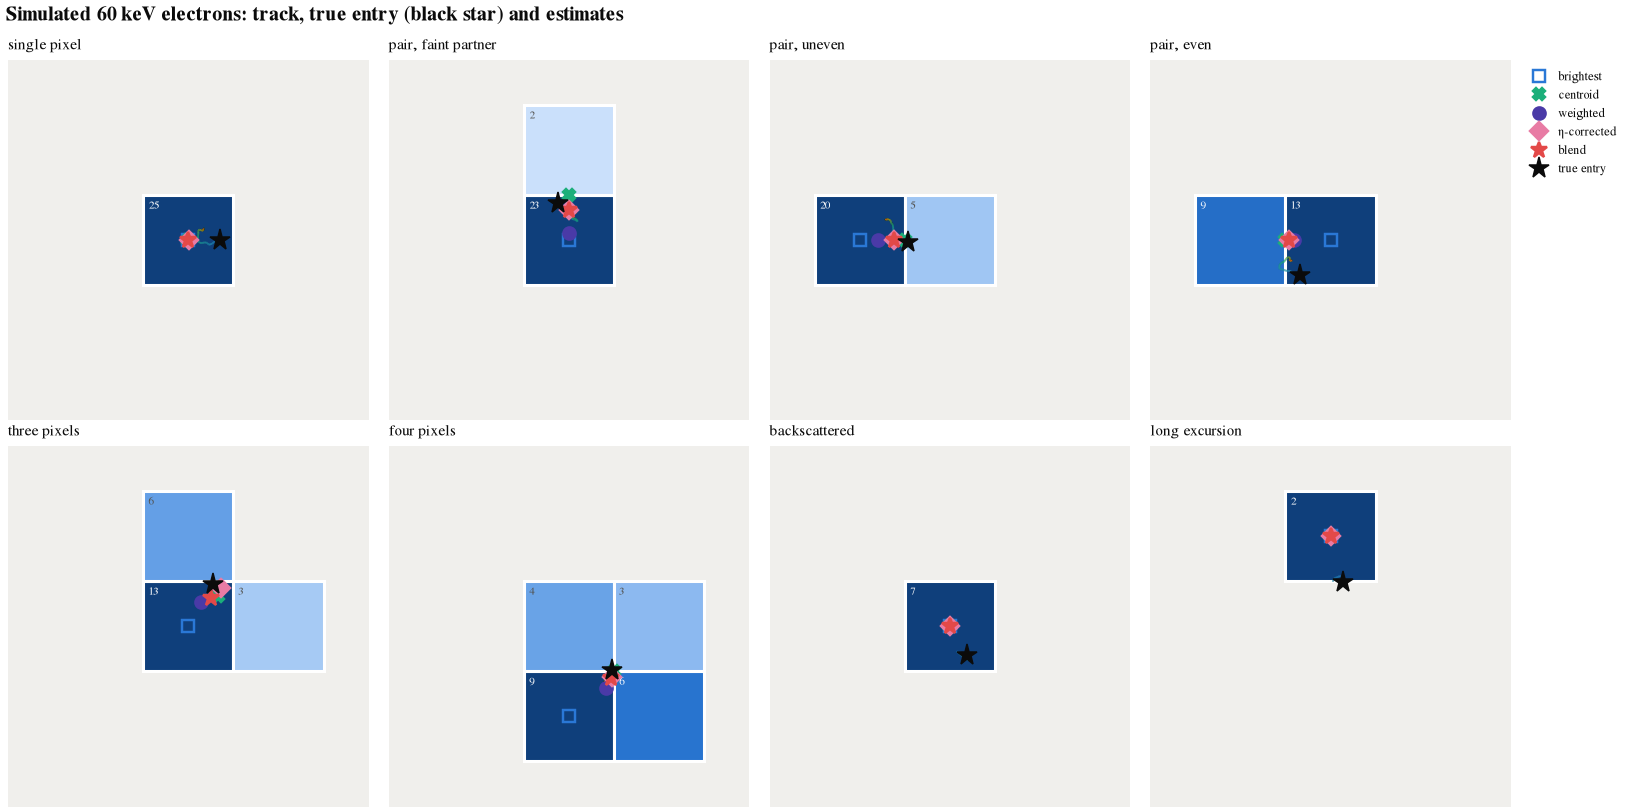

In [14]:
share_sim = mag
picks = {
    'single pixel': np.flatnonzero(test & (sim_n == 1)),
    'pair, faint partner': np.flatnonzero(test & (sim_n == 2) & (share_sim < 0.08)),
    'pair, uneven': np.flatnonzero(test & (sim_n == 2) & (share_sim > 0.1) & (share_sim < 0.2)),
    'pair, even': np.flatnonzero(test & (sim_n == 2) & (share_sim > 0.4)),
    'three pixels': np.flatnonzero(test & (sim_n == 3)),
    'four pixels': np.flatnonzero(test & (sim_n == 4)),
    'backscattered': np.flatnonzero(test & (escaped > 0.5 * E_BEAM_KEV)),
    'long excursion': np.flatnonzero(test & (np.hypot(sim_impact['weighted'][0] - true_x, sim_impact['weighted'][1] - true_y) > 0.5)),
}
original = np.flatnonzero(sim_keep)  # index of each kept cluster in the simulation, for its random stream
rng = np.random.default_rng(4)
fig, axes = plt.subplots(2, 4, figsize=(15, 7.6))
for ax, (title, ks) in zip(axes.flat, picks.items()):
    i = rng.choice(ks)
    hit_y, hit_x = np.nonzero(sim_tot[i] >= 0)
    draw_pixels(ax, hit_x - 2, hit_y - 2, sim_tot[i][hit_y, hit_x], {name: (v[0][i], v[1][i]) for name, v in sim_impact.items()}, (0, 0))
    track, track_energy = trajectory(
        E_BEAM_KEV, true_x[i] * PIXEL_UM, true_y[i] * PIXEL_UM, 1 * 1000003 + original[i]
    )  # the same random stream as in simulate()
    colored_path(ax, track[:, 0] / PIXEL_UM, track[:, 1] / PIXEL_UM, track_energy, 1.2)
    ax.plot(true_x[i], true_y[i], marker='*', color=INK, ms=14, ls='none', label='true entry', zorder=6)
    ax.set_title(title, fontsize=10)
axes[0, -1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
fig.suptitle(f'Simulated {E_BEAM_KEV:.0f} keV electrons: track, true entry (black star) and estimates', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. The test: a sharp edge in the real beam

The simulation says to place the electron between `centroid` and `weighted`. Real data can check
this without any model, on the sharp rim at the bottom of the beam: the better the estimator, the
steeper the edge it draws. Two precautions:

* Only the parts of the rim tilted more than 17° from the pixel rows are used. Where the rim runs along
  a row, impacts at pixel centers all land at the same distance from it and the profile breaks into
  spikes.
* Each profile's rising flank is fitted with a blurred step, and its blur σ is compared. Fitting even
  and odd clusters separately gives the statistical error. The rim is fitted from the raw event image,
  which does not depend on any estimator.

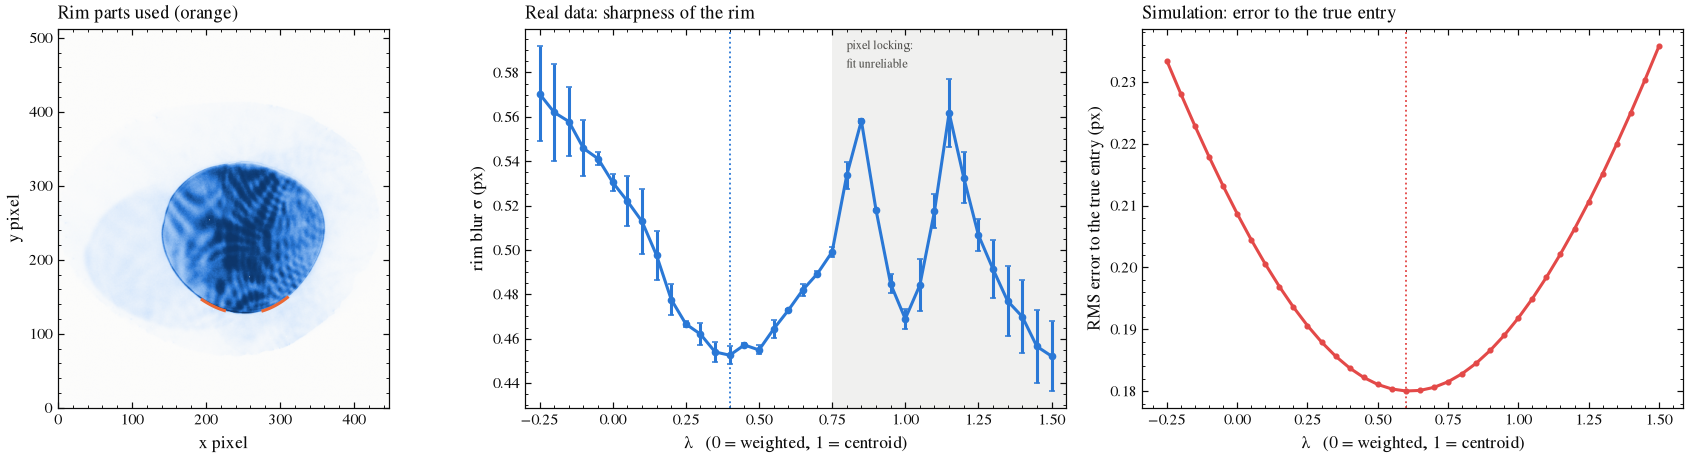

sharpest real rim at λ = 0.40 (σ = 0.453 px, weighted 0.530 px); simulation’s best λ = 0.60


,rim blur σ (px),±
estimator,,
brightest,0.705,0.026
centroid,0.469,0.004
weighted,0.530,0.004
η-corrected,0.479,0.011
blend,0.473,0.001


In [15]:
beam = np.zeros((HEIGHT, WIDTH))
for part in merge_sort(files, columns=('x', 'y', 'toa')):
    np.add.at(beam, (part['y'].astype(np.int64), part['x'].astype(np.int64)), 1)
X_RIM = np.arange(195, 311)  # the lower arc of the disk
rim_y = []
for xc in X_RIM:
    col = beam[110:175, xc]
    level = (np.median(col[:5]) + np.median(col[-8:])) / 2  # half way up the step
    j = np.flatnonzero(col >= level)[0]
    rim_y.append(110 + j - 1 + (level - col[j - 1]) / (col[j] - col[j - 1]))
rim = np.polyfit(X_RIM, rim_y, 4)
xb_all, yb_all = stats.x_b.to_numpy(), stats.y_b.to_numpy()
near = (xb_all >= X_RIM[0] - 2) & (xb_all <= X_RIM[-1] + 2) & (yb_all > 100) & (yb_all < 180)
odd = (np.arange(len(stats)) % 2 == 1)[near]


def blurred_step(d, low, high, d0, sigma):
    return low + (high - low) * 0.5 * (1 + erf((d - d0) / (np.sqrt(2) * sigma)))


def edge_blur(px, py):
    # Blurred-step σ of the rim profile (tilted parts only), and half the even/odd difference.
    px, py = px[near], py[near]
    slope = np.polyval(np.polyder(rim), px)
    d = (py - np.polyval(rim, px)) / np.sqrt(1 + slope**2)
    use = (px >= X_RIM[0]) & (px <= X_RIM[-1]) & (np.abs(slope) > 0.3)
    bins = np.arange(-3, 3.001, 0.05)
    mid = (bins[1:] + bins[:-1]) / 2
    flank = mid < 0.7
    sigmas = []
    for sel in (use, use & ~odd, use & odd):
        h, _ = np.histogram(d[sel], bins)
        p, _ = curve_fit(
            blurred_step,
            mid[flank],
            h[flank],
            p0=[h[:10].mean(), h[mid > 0.5].mean(), 0.2, 0.3],
            bounds=([-np.inf, -np.inf, -2, 0.05], [np.inf, np.inf, 2, 2]),
        )
        sigmas.append(p[3])
    return sigmas[0], abs(sigmas[1] - sigmas[2]) / 2


impact['blend'] = blend(impact, LAMBDA)
rim_lam = np.array([edge_blur(*blend(impact, lam)) for lam in LAMBDAS])
RELIABLE = LAMBDAS <= 0.75  # closer to centroid, impacts lock onto fixed sub-pixel points and the step fit breaks down
RIM_LAMBDA = LAMBDAS[RELIABLE][np.argmin(rim_lam[RELIABLE, 0])]
rim_table = pd.DataFrame(
    [{'estimator': name, 'rim blur σ (px)': s, '±': e} for name, (s, e) in ((name, edge_blur(*impact[name])) for name in impact)]
).set_index('estimator')

fig, (ax_beam, ax_rim, ax_sim) = plt.subplots(1, 3, figsize=(16, 4.4), gridspec_kw={'width_ratios': [1, 1.2, 1.2]})
ax_beam.imshow(beam, origin='lower', cmap=SEQUENTIAL, vmax=np.percentile(beam, 99.7))
tilted = np.abs(np.polyval(np.polyder(rim), X_RIM)) > 0.3
ax_beam.plot(np.where(tilted, X_RIM, np.nan), np.polyval(rim, X_RIM), color=ORANGE, lw=2)
ax_beam.set(title='Rim parts used (orange)', xlabel='x pixel', ylabel='y pixel')
ax_beam.grid(False)
ax_rim.errorbar(LAMBDAS, rim_lam[:, 0], yerr=rim_lam[:, 1], color=BLUE, marker='o', ms=4, lw=2, capsize=2)
ax_rim.axvline(RIM_LAMBDA, color=BLUE, ls=':', lw=1.2)
ax_rim.set_xlim(LAMBDAS[0] - 0.05, LAMBDAS[-1] + 0.05)
ax_rim.axvspan(0.75, LAMBDAS[-1] + 0.05, color=MUTED, alpha=0.12, lw=0)
ax_rim.text(0.8, 0.98, 'pixel locking:\nfit unreliable', transform=ax_rim.get_xaxis_transform(), fontsize=8, color=INK_2, va='top')
ax_rim.set(xlabel='λ   (0 = weighted, 1 = centroid)', ylabel='rim blur σ (px)', title='Real data: sharpness of the rim')
ax_sim.plot(LAMBDAS, sim_lam, color=RED, lw=2, marker='o', ms=3)
ax_sim.axvline(LAMBDA, color=RED, ls=':', lw=1.2)
ax_sim.set(xlabel='λ   (0 = weighted, 1 = centroid)', ylabel='RMS error to the true entry (px)', title='Simulation: error to the true entry')
plt.tight_layout()
plt.show()
print(
    f'sharpest real rim at λ = {RIM_LAMBDA:.2f} (σ = {rim_lam[LAMBDAS == RIM_LAMBDA, 0][0]:.3f} px, weighted {rim_lam[LAMBDAS == 0, 0][0]:.3f} px); simulation’s best λ = {LAMBDA:.2f}'
)
rim_table.style.format('{:.3f}')

**The real data agree.** Moving from `weighted` (λ = 0) toward `centroid` sharpens the real rim, and the
sharpest edge is at λ ≈ 0.4, in the same broad minimum as the simulation's 0.6. Close to λ = 1 the
impacts start to lock onto a few sub-pixel points (section 4), the profile breaks into spikes and the
step fit becomes unreliable (the bumps at 0.85 and 1.15, and `centroid`'s value in the table), so only
λ ≤ 0.75 is searched. The rim is itself almost half a pixel wide, which hides finer differences:
`blend`, `η-corrected` and `centroid` agree within the errors here. What the rim does show clearly is
that `weighted` is blurrier than all three, and `brightest` much more so.

## 9. A check the fit did not use: deposited energy

The fitted response turns summed ToT back into deposited energy, roughly `E ≈ n·threshold + gain·(ToT −
n·offset)`. Every electron arrives with the beam energy, so the spectrum should peak there, with a tail
from electrons that backscatter and carry part of their energy away. The simulation predicts that tail
without having been fitted to it.

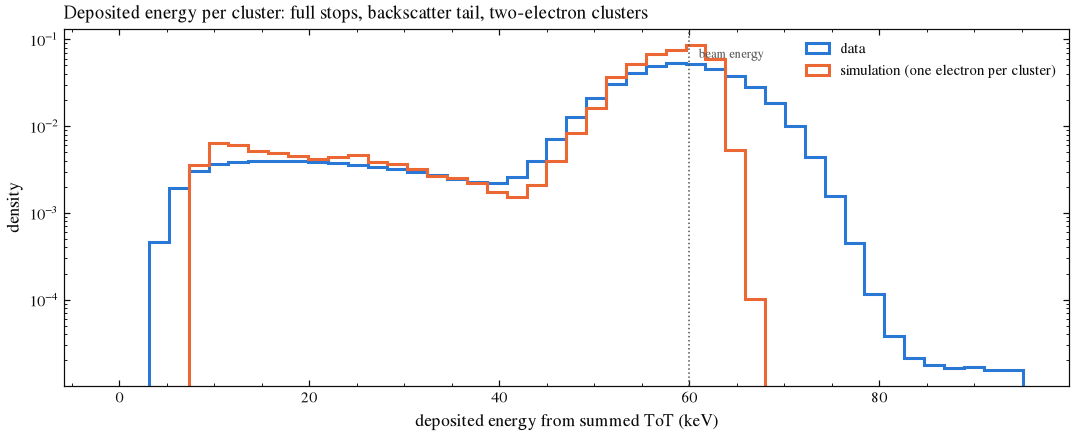

clusters below 36 keV: data 10.3%, simulation 12.3%


In [16]:
def deposited_kev(table):
    return table.n.to_numpy() * best.threshold_keV + best.gain_keV * (table.tot.to_numpy() - table.n.to_numpy() * best.offset)


e_data, e_sim = deposited_kev(stats), deposited_kev(sim)
bins = np.arange(-0.5, 1.6 * E_BEAM_KEV / best.gain_keV) * best.gain_keV  # one bin per ToT step
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.hist(e_data, bins, density=True, histtype='step', lw=2, color=BLUE, label='data')
ax.hist(e_sim, bins, density=True, histtype='step', lw=2, color=ORANGE, label='simulation (one electron per cluster)')
ax.axvline(E_BEAM_KEV, color=INK_2, ls=':', lw=1)
ax.text(E_BEAM_KEV + 1, 0.92, 'beam energy', fontsize=8, color=INK_2, transform=ax.get_xaxis_transform())
ax.set(
    yscale='log',
    xlabel='deposited energy from summed ToT (keV)',
    ylabel='density',
    title='Deposited energy per cluster: full stops, backscatter tail, two-electron clusters',
)
ax.legend()
plt.tight_layout()
plt.show()
print(f'clusters below {0.6 * E_BEAM_KEV:.0f} keV: data {np.mean(e_data < 0.6 * E_BEAM_KEV):.1%}, simulation {np.mean(e_sim < 0.6 * E_BEAM_KEV):.1%}')

## 10. Summary

* **Storage.** Nine integer sums per cluster (24 bytes), collected in the same pass that sorts and
  clusters through `cluster_tables(..., summarize=...)`, give every estimator here; the events can be
  dropped.
* **Physics.** A 60 keV electron travels a 36 µm winding path and deposits half its energy in the last
  10 µm. The bright end of a cluster is where the electron stopped, not where it entered.
* **The data alone cannot choose.** `weighted` and `η-corrected` disagree about where pairs sit, and
  only ground truth can settle it.
* **The simulation, fitted to the real clusters** (diffusion σ ≈ 10 µm, threshold ≈ 8 keV, ≈ 2.1 keV per
  ToT), reproduces the cluster sizes and ToT splits, and predicts the backscatter tail it was not fitted
  to.
* **The best simple centroid** is `λ·centroid + (1 − λ)·weighted` with λ ≈ 0.6 in the simulation,
  0.5–0.6 along the whole family of detector fits, and ≈ 0.4 on the real rim. It matches a full
  lookup table, improves on `weighted` from 11.8 to 10.9 µm per axis, and gives a visibly sharper real
  edge.

**Recommendation:** use the blend with **λ = 0.5**, between the simulation's and the rim's best, where
both curves are flat. `summarize_clusters` stores both centroids (`x_mean, y_mean` next to the ToT-weighted
`x, y`), so the impact is `0.5·x_mean + 0.5·x` straight from its tables. The value of λ is for 60 keV; for another beam energy, rerun
this notebook with `E_BEAM_KEV` changed.